In [1]:
import numpy as np
import globals as gl
import nibabel as nb
import os
import matplotlib.pyplot as plt
import pandas as pd
from util import concat_hrf, group_by_dict_fields

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


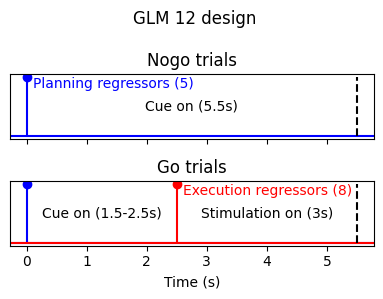

In [2]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, figsize=(4, 3))

axs[0].axhline(0, color='blue')
axs[0].stem(0, 1, linefmt='b-', )
axs[0].set_title('Nogo trials')
axs[0].vlines(5.5, 0, 1,  color='k', ls='--')
axs[0].text(2.75, .5, 'Cue on (5.5s)', ha='center', va='center')
axs[0].text(.1, 1, 'Planning regressors (5)', ha='left', va='top', color='blue')
axs[0].set_yticks([])

axs[1].axhline(0, color='blue')
axs[1].stem(0, 1, linefmt='b-')
axs[1].set_title('Go trials')
axs[1].axhline(0, color='red')
axs[1].stem(2.5, 1, linefmt='r-')
axs[1].vlines(5.5, 0, 1,  color='k', ls='--')
axs[1].set_yticks([])
axs[1].text(1.25, .5, 'Cue on (1.5-2.5s)', ha='center', va='center')
axs[1].text(4, .5, 'Stimulation on (3s)', ha='center', va='center')
axs[1].text(2.6, 1, 'Execution regressors (8)', ha='left', va='top', color='red')
axs[1].set_xlabel('Time (s)')

fig.suptitle(f'GLM 12 design')
fig.tight_layout()

In [3]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 0
glm = 12
snS = [ 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,]

Ts = [os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', 'T.mat') for sn in snS]

T = concat_hrf(Ts)
T_avg = group_by_dict_fields(T, ['GoNogo', 'SN'], ['y_adj'])

tAx = np.linspace(-10, 20, T['y_adj'].shape[-1])

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(8, 6))
for i in range(2):
    for j in range(4):

        hem = T['hem']==Hem
        roi = T['name']==rois[r]
        go = T['GoNogo']=='go'

        y_adj_go = np.nanmean(T['y_adj'][go & roi & hem], axis=0)
        y_adj_nogo = np.nanmean(T['y_adj'][~go & roi & hem], axis=0)

        y_adj_go_err = np.nanstd(T['y_adj'][go & roi & hem], axis=0) / np.sqrt(len(snS))
        y_adj_nogo_err = np.nanstd(T['y_adj'][~go & roi & hem], axis=0) / np.sqrt(len(snS))

        axs[i, j].plot(tAx, y_adj_go, color='forestgreen', label='go adj', ls='-')
        axs[i, j].plot(tAx,y_adj_nogo, color='darkmagenta', label='nogo adj', ls='-')
        axs[i, j].fill_between(tAx,y_adj_go - y_adj_go_err, y_adj_go + y_adj_go_err,
                               color='forestgreen', alpha=.2, lw=0)
        axs[i, j].fill_between(tAx,y_adj_nogo - y_adj_nogo_err, y_adj_nogo + y_adj_nogo_err,
                               color='darkmagenta', alpha=.2, lw=0)

        axs[i, j].axvline(1.5, color='k', ls='-')
        axs[i, j].axvline(5.5, color='k', ls='--')

        axs[i, j].set_title(rois[r])

        r = r + 1

fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to startTRReal (TR)')
fig.suptitle(f'Activation relative to trial onset (hemisphere:{Hem}, glm:{glm})')

fig.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: '/cifs/diedrichsen/data/SensoriMotorPrediction/smp2/glm12/subj105/T.mat'

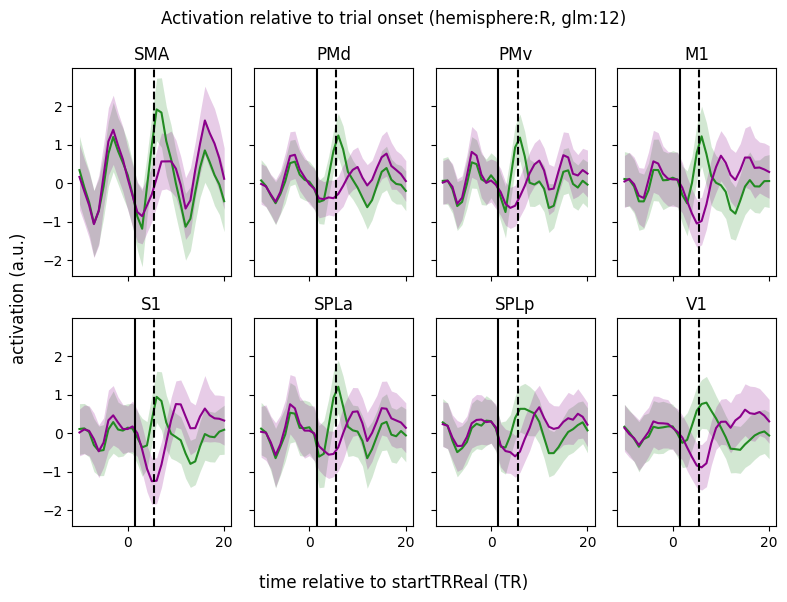

In [11]:
Hem = 'R'
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(8, 6))
for i in range(2):
    for j in range(4):

        hem = T['hem']==Hem
        roi = T['name']==rois[r]
        go = T['GoNogo']=='go'

        y_adj_go = np.nanmean(T['y_adj'][go & roi & hem], axis=0)
        y_adj_nogo = np.nanmean(T['y_adj'][~go & roi & hem], axis=0)

        y_adj_go_err = np.nanstd(T['y_adj'][go & roi & hem], axis=0) / np.sqrt(len(snS))
        y_adj_nogo_err = np.nanstd(T['y_adj'][~go & roi & hem], axis=0) / np.sqrt(len(snS))

        axs[i, j].plot(tAx, y_adj_go, color='forestgreen', label='go adj', ls='-')
        axs[i, j].plot(tAx,y_adj_nogo, color='darkmagenta', label='nogo adj', ls='-')
        axs[i, j].fill_between(tAx,y_adj_go - y_adj_go_err, y_adj_go + y_adj_go_err,
                               color='forestgreen', alpha=.2, lw=0)
        axs[i, j].fill_between(tAx,y_adj_nogo - y_adj_nogo_err, y_adj_nogo + y_adj_nogo_err,
                               color='darkmagenta', alpha=.2, lw=0)

        axs[i, j].axvline(1.5, color='k', ls='-')
        axs[i, j].axvline(5.5, color='k', ls='--')

        axs[i, j].set_title(rois[r])

        r = r + 1

fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to startTRReal (TR)')
fig.suptitle(f'Activation relative to trial onset (hemisphere:{Hem}, glm:{glm})')

fig.tight_layout()